# Testing the library

In [4]:
!nvidia-smi

Thu Jul  9 04:02:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...    Off |   00000000:01:00.0  On |                  N/A |
| N/A   57C    P5             16W /  115W |     416MiB /   6144MiB |     29%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# pip install tqdm ipywidgets
# pip install scipy

In [ ]:
###import optical_flow_3D

In [1]:
from optical_flow_3D import OF3D

In [2]:
import numpy as np

In [3]:
farneback = OF3D.Farneback3D(
    iters=5,
    num_levels=5,
    scale=0.5,
    spatial_size=7,
    presmoothing=7,
    filter_type="box",
    filter_size=21,
)

In [4]:
depth = 64
height = 64
width = 64

vol_1 = np.random.rand(depth, height, width)
vol_2 = np.random.rand(depth, height, width)

In [5]:
output_vz, output_vy, output_vx, output_confidence = farneback.calculate_flow(
    vol_1, vol_2, 
    start_point=(0, 0, 0),
    total_vol=(depth, height, width),
    sub_volume=(depth, height, width),
    overlap=(4, 4, 4),
    threadsperblock=(8, 8, 8),
)

Running 3D Farneback optical flow with the following parameters:
Iters: 5 | Levels: 5 | Scale: 0.5 | Kernel: 7 | Filter: box-21 | Presmoothing: 7


/home/vruiz/envs/cupy/lib/python3.14/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/vruiz/envs/cupy/lib/python3.14/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/vruiz/envs/cupy/lib/python3.14/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/vruiz/envs/cupy/lib/python3.14/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/vruiz/envs/cupy/lib/python3.14/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 

In [6]:
# %pip install matplotlib
import matplotlib.pyplot as plt

In [7]:
# 1. Select a slice to visualize (e.g., the middle slice along the z-axis)
slice_idx = depth // 2
vx_slice = output_vx[slice_idx, :, :]
vy_slice = output_vy[slice_idx, :, :]

In [8]:
# 2. Downsample the data for better visualization
skip = 4
vx_downsampled = vx_slice[::skip, ::skip]
vy_downsampled = vy_slice[::skip, ::skip]

In [9]:
# 3. Create the grid of coordinates for the arrows
x_coords, y_coords = np.meshgrid(
    np.arange(0, width, skip),
    np.arange(0, height, skip)
)

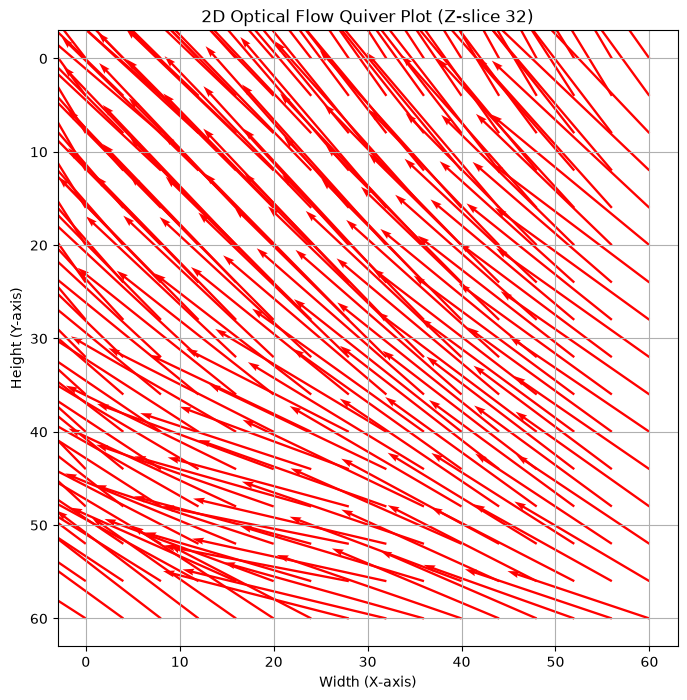

In [10]:
# 4. Create the quiver plot
plt.figure(figsize=(8, 8))
plt.quiver(x_coords, y_coords, vx_downsampled, vy_downsampled, color='r', angles='xy', scale_units='xy', scale=1)
plt.title(f'2D Optical Flow Quiver Plot (Z-slice {slice_idx})')
plt.gca().invert_yaxis() # Invert y-axis to match image coordinates (origin at top-left)
plt.xlabel('Width (X-axis)')
plt.ylabel('Height (Y-axis)')
plt.grid()
plt.show()